In [1]:
import pandas as pd

In [4]:
parametric_data_onlyP = pd.read_pickle('parametric_data/data_onlyP.pkl')

In [7]:
new_names_mapping = {
    'P_bar': 'P (bar)',
    'T_C': 'T (ºC)',
    'v_H2_in': r'$\mathrm{v_{H_2,in}}$ (mL/min)',
    'v_CO_in': r'$\mathrm{v_{CO,in}}$ (mL/min)',
    'H2_CO': r'$\mathrm{H_2/CO}$',
    'X_CO': r'$\mathrm{X_{CO}}$',
    'X_H2': r'$\mathrm{X_{H_2}}$',
    'C9_C15_sel': r'$\mathrm{Sel_{C9-C15}}$',
}

parametric_data_onlyP = parametric_data_onlyP.rename(columns=new_names_mapping)

parametric_data_onlyP[['C1-C3', 
                 'C9-C15', 
                 'C16+', 
                 r'$\mathrm{\dot{m}_{H_2O}}$ (g/d)']] = parametric_data_onlyP[['m_C1_C3', 
                                                                        'm_C9_C15', 
                                                                        'm_C16p', 
                                                                        'm_water']]*1000*60*60*24

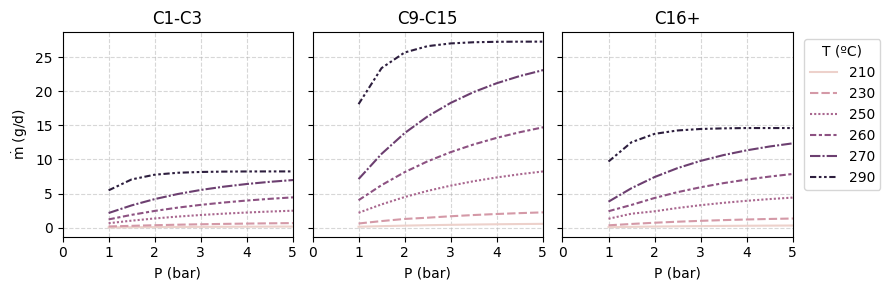

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns (carbon fractions) to iterate over
fractions = ['C1-C3', 'C9-C15', 'C16+']

# Initialize subplots
fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

for i, col in enumerate(fractions):
    # Melt only the necessary columns for the current subplot
    data_melted = parametric_data_onlyP[['P (bar)', 'T (ºC)', col]].melt(
        id_vars=['P (bar)', 'T (ºC)']
    )
    
    # Plotting
    sns.lineplot(
        data=data_melted,
        x='P (bar)',
        y='value',
        hue='T (ºC)',
        style='T (ºC)',
        ax=ax[i],
        legend=(i == 2) # Show legend only on the last plot to save space
    )
    
    # Formatting each subplot
    ax[i].set_title(col)
    ax[i].set_xlim(0,5)
    ax[i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[i].set_ylabel(r'$\mathrm{\dot{m}}$ (g/d)' if i == 0 else "")

# Adjust legend position on the last axis
ax[2].legend(bbox_to_anchor=(1.02, 1), title='T (ºC)', loc='upper left')

plt.tight_layout()

# Save logic
# fig_name = 'parametric_study_P.pdf'
# save_path = f'Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\{fig_name}'
# plt.savefig(save_path, bbox_inches='tight')
plt.show()